# Advanced Text Analysis with NLP Techniques

This notebook performs comprehensive text analysis on financial news headlines using:
- **TF-IDF** for keyword importance scoring
- **CountVectorizer** for common phrases and n-grams extraction
- **LDA (Latent Dirichlet Allocation)** for topic modeling and theme discovery
- **Text preprocessing** and **sentiment analysis**

The analysis will identify:
- Common keywords and phrases in headlines
- Significant topics and recurring themes
- Financial terminology patterns (e.g., "FDA approval", "price target", "earnings beat")

In [1]:
# Import necessary libraries for NLP analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from datetime import datetime
import warnings

# NLP and text processing libraries
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.preprocessing import normalize
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import spacy

# Download required NLTK data
try:
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('vader_lexicon', quiet=True)
except:
    pass

# Suppress warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

print("NLP libraries imported successfully!")

NLP libraries imported successfully!


## 1. Load and Preprocess Text Data

In [2]:
# Load the news data
data_path = '../Data/newsData/raw_analyst_ratings.csv'
try:
    df = pd.read_csv(data_path)
    print("News data loaded successfully!")
    print(f"Dataset shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Sample headlines:")
    print(df['headline'].head(10).tolist())
except FileNotFoundError:
    print(f"Error: Data file not found at {data_path}")
    # Create sample data for demonstration
    df = pd.DataFrame({
        'headline': [
            'Apple beats earnings expectations with strong iPhone sales',
            'FDA approves new drug treatment for diabetes',
            'Tech stocks rise as Microsoft announces AI partnership',
            'Oil prices surge amid Middle East tensions',
            'Federal Reserve signals potential rate cuts',
            'Tesla stock plunges after disappointing delivery numbers',
            'Gold reaches all-time high as investors seek safety',
            'Amazon announces $15 billion investment in logistics',
            'Bank of America raises price target for Google stock'
        ],
        'publisher': ['Reuters', 'Bloomberg', 'CNBC', 'Reuters', 'WSJ', 'Bloomberg', 'Reuters', 'CNBC', 'WSJ', 'Bloomberg'],
        'stock': ['AAPL', 'AAPL', 'MSFT', 'OIL', 'FED', 'TSLA', 'GLD', 'AMZN', 'GOOGL'],
        'date': ['2024-01-15', '2024-01-16', '2024-01-17', '2024-01-18', '2024-01-19', '2024-01-20', '2024-01-21', '2024-01-22', '2024-01-23']
    })
    print("Created sample financial headlines for demonstration.")

News data loaded successfully!
Dataset shape: (1407328, 6)
Columns: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']
Sample headlines:
['Stocks That Hit 52-Week Highs On Friday', 'Stocks That Hit 52-Week Highs On Wednesday', '71 Biggest Movers From Friday', "46 Stocks Moving In Friday's Mid-Day Session", 'B of A Securities Maintains Neutral on Agilent Technologies, Raises Price Target to $88', 'CFRA Maintains Hold on Agilent Technologies, Lowers Price Target to $85', 'UBS Maintains Neutral on Agilent Technologies, Raises Price Target to $87', 'Agilent Technologies shares are trading higher after the company reported better-than-expected Q2 EPS and sales results.', 'Wells Fargo Maintains Overweight on Agilent Technologies, Raises Price Target to $95', '10 Biggest Price Target Changes For Friday']


## 2. Text Preprocessing and Cleaning

In [3]:
# Text preprocessing function
def preprocess_text(text):
    """Clean and preprocess text for NLP analysis"""
    if pd.isna(text):
        return ""
    
    # Convert to lowercase
    text = str(text).lower()
    
    # Remove special characters but keep financial symbols
    text = re.sub(r'[^a-zA-Z0-9\s\$%]', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply preprocessing
df['cleaned_headline'] = df['headline'].apply(preprocess_text)

print(f"Original headlines: {df['headline'].iloc[0]}")
print(f"Cleaned headlines: {df['cleaned_headline'].iloc[0]}")
print(f"\nTotal headlines processed: {len(df)}")

Original headlines: Stocks That Hit 52-Week Highs On Friday
Cleaned headlines: stocks that hit 52week highs on friday

Total headlines processed: 1407328


## 3. TF-IDF Analysis for Keyword Importance

In [4]:


# TF-IDF Vectorization for keyword importance
def analyze_tfidf_keywords(headlines, top_n=20):
    """Analyze headlines using TF-IDF to identify important keywords"""
    # Initialize TF-IDF Vectorizer
    tfidf_vectorizer = TfidfVectorizer(
        max_features=1000,
        ngram_range=(1, 2),  # unigrams and bigrams
        stop_words='english',
        min_df=2,  # appear in at least 2 documents
        max_df=0.8  # appear in at most 80% of documents
    )
    
    # Fit and transform the headlines
    tfidf_matrix = tfidf_vectorizer.fit_transform(headlines)
    
    # Get feature names and calculate mean TF-IDF scores
    feature_names = tfidf_vectorizer.get_feature_names_out()
    mean_tfidf_scores = np.mean(tfidf_matrix.toarray(), axis=0)
    
    # Create dataframe of keywords and their scores
    keyword_scores = pd.DataFrame({
        'keyword': feature_names,
        'tfidf_score': mean_tfidf_scores
    })
    
    # Sort by TF-IDF score
    top_keywords = keyword_scores.sort_values('tfidf_score', ascending=False).head(top_n)
    
    return top_keywords, tfidf_vectorizer, tfidf_matrix

# Perform TF-IDF analysis
top_keywords, tfidf_vectorizer, tfidf_matrix = analyze_tfidf_keywords(df['cleaned_headline'])

print("TOP KEYWORDS BY TF-IDF SCORE:")
print("-" * 50)
for i, row in top_keywords.iterrows():
    print(f"{i+1:2d}. {row['keyword']:<25} TF-IDF: {row['tfidf_score']:.4f}")

TOP KEYWORDS BY TF-IDF SCORE:
--------------------------------------------------
864. stocks                    TF-IDF: 0.0263
958. vs                        TF-IDF: 0.0232
313. est                       TF-IDF: 0.0212
757. reports                   TF-IDF: 0.0191
307. eps                       TF-IDF: 0.0185
823. shares                    TF-IDF: 0.0182
294. earnings                  TF-IDF: 0.0176
936. update                    TF-IDF: 0.0171
514. market                    TF-IDF: 0.0167
129. announces                 TF-IDF: 0.0157
156. benzingas                 TF-IDF: 0.0151
288. downgrades                TF-IDF: 0.0150
941. upgrades                  TF-IDF: 0.0146
186. buy                       TF-IDF: 0.0142
694. pt                        TF-IDF: 0.0138
783. sales                     TF-IDF: 0.0134
786. says                      TF-IDF: 0.0119
721. raises                    TF-IDF: 0.0114
591. new                       TF-IDF: 0.0110
675. price                     TF-IDF: 0.0107

## 4. CountVectorizer for Common Phrases and N-grams

In [5]:
# Ensure data is loaded
if 'df' not in locals():
    # Load the news data
    data_path = '../Data/newsData/raw_analyst_ratings.csv'
    try:
        df = pd.read_csv(data_path)
        # Apply preprocessing if not already done
        if 'cleaned_headline' not in df.columns:
            def preprocess_text(text):
                if pd.isna(text):
                    return ""
                text = str(text).lower()
                text = re.sub(r'[^a-zA-Z0-9\s\$%]', '', text)
                text = re.sub(r'\s+', ' ', text).strip()
                return text
            df['cleaned_headline'] = df['headline'].apply(preprocess_text)
    except FileNotFoundError:
        print("Data file not found. Please run cell 3 first.")
        raise

# CountVectorizer for common phrases and n-grams
def analyze_common_phrases(headlines, top_n=20):
    """Analyze headlines using CountVectorizer for common phrases"""
    # Initialize CountVectorizer for different n-gram ranges
    analyzers = {
        'unigrams': CountVectorizer(ngram_range=(1,1), max_features=50, stop_words='english'),
        'bigrams': CountVectorizer(ngram_range=(2,2), max_features=50, stop_words='english'),
        'trigrams': CountVectorizer(ngram_range=(3,3), max_features=30, stop_words='english')
    }
    
    results = {}
    
    for name, vectorizer in analyzers.items():
        # Fit and transform
        count_matrix = vectorizer.fit_transform(headlines)
        
        # Get feature names and counts
        feature_names = vectorizer.get_feature_names_out()
        phrase_counts = np.sum(count_matrix.toarray(), axis=0)
        
        # Create dataframe
        phrase_df = pd.DataFrame({
            'phrase': feature_names,
            'count': phrase_counts
        })
        
        # Sort by count and get top phrases
        top_phrases = phrase_df.sort_values('count', ascending=False).head(top_n)
        results[name] = top_phrases
    
    return results

# Analyze common phrases
phrase_analysis = analyze_common_phrases(df['cleaned_headline'])

# Display results
for ngram_type, phrases in phrase_analysis.items():
    print(f"\nTOP {ngram_type.upper()} (Common Phrases):")
    print("-" * 40)
    for i, row in phrases.iterrows():
        print(f"{i+1:2d}. {row['phrase']:<30} Count: {row['count']:3d}")


TOP UNIGRAMS (Common Phrases):
----------------------------------------
50. vs                             Count: 162094
45. stocks                         Count: 161868
14. est                            Count: 140589
13. eps                            Count: 128919
43. shares                         Count: 114183
37. reports                        Count: 108706
48. update                         Count: 91680
22. market                         Count: 90879
11. earnings                       Count: 87185
38. sales                          Count: 79529
31. pt                             Count: 73043
 2. announces                      Count: 66531
30. price                          Count: 64231
 6. buy                            Count: 64060
10. downgrades                     Count: 61942
47. trading                        Count: 61156
 4. benzingas                      Count: 57985
36. raises                         Count: 57798
49. upgrades                       Count: 56804
46. targe

## 5. Topic Modeling with LDA

In [7]:


# LDA Topic Modeling for theme discovery
def perform_topic_modeling(headlines, n_topics=5, n_top_words=10):
    """Perform LDA topic modeling to discover themes"""
    # Use CountVectorizer for LDA (works better than TF-IDF for topic modeling)
    vectorizer = CountVectorizer(
        max_features=100,
        ngram_range=(1, 2),
        stop_words='english',
        min_df=2,
        max_df=0.8
    )
    
    # Create document-term matrix
    doc_term_matrix = vectorizer.fit_transform(headlines)
    
    # Perform LDA
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        max_iter=10,
        learning_method='online'
    )
    
    lda.fit(doc_term_matrix)
    
    # Get topic words
    feature_names = vectorizer.get_feature_names_out()
    topics = []
    
    for topic_idx, topic in enumerate(lda.components_):
        top_words_idx = topic.argsort()[-n_top_words:][::-1]
        top_words = [feature_names[i] for i in top_words_idx]
        topics.append({
            'topic_id': topic_idx + 1,
            'words': top_words,
            'weights': topic[top_words_idx]
        })
    
    return lda, vectorizer, topics, doc_term_matrix

# Perform topic modeling
lda_model, lda_vectorizer, topics, doc_term_matrix = perform_topic_modeling(df['cleaned_headline'])

print("DISCOVERED TOPICS:")
print("=" * 60)
for topic in topics:
    print(f"\nTopic {topic['topic_id']}:")
    words_with_weights = list(zip(topic['words'], topic['weights']))
    for i, (word, weight) in enumerate(words_with_weights):
        print(f"  {i+1}. {word:<20} (weight: {weight:.3f})")

DISCOVERED TOPICS:

Topic 1:
  1. vs                   (weight: 163761.730)
  2. est                  (weight: 141816.273)
  3. eps                  (weight: 127839.844)
  4. reports              (weight: 108555.074)
  5. sales                (weight: 82500.748)
  6. q4                   (weight: 40345.176)
  7. q1                   (weight: 38490.818)
  8. sees                 (weight: 38132.962)
  9. estimate             (weight: 37925.220)
  10. q2                   (weight: 37810.444)

Topic 2:
  1. stocks               (weight: 112703.737)
  2. higher               (weight: 47848.074)
  3. session              (weight: 45113.167)
  4. moving               (weight: 42370.383)
  5. stocks moving        (weight: 40031.831)
  6. premarket            (weight: 38924.760)
  7. stock                (weight: 38840.143)
  8. watch                (weight: 30015.216)
  9. sector               (weight: 29495.671)
  10. new                  (weight: 26541.087)

Topic 3:
  1. earnings           

## 6. Financial Terminology Detection

In [8]:
# Ensure data is loaded
if 'df' not in locals():
    # Load the news data
    data_path = '../Data/newsData/raw_analyst_ratings.csv'
    try:
        df = pd.read_csv(data_path)
        # Apply preprocessing if not already done
        if 'cleaned_headline' not in df.columns:
            def preprocess_text(text):
                if pd.isna(text):
                    return ""
                text = str(text).lower()
                text = re.sub(r'[^a-zA-Z0-9\s\$%]', '', text)
                text = re.sub(r'\s+', ' ', text).strip()
                return text
            df['cleaned_headline'] = df['headline'].apply(preprocess_text)
    except FileNotFoundError:
        print("Data file not found. Please run cell 3 first.")
        raise

# Define financial terminology patterns
financial_terms = {
    'earnings': ['earnings', 'profit', 'revenue', 'beat', 'miss', 'estimate', 'quarterly', 'annual'],
    'regulatory': ['fda', 'sec', 'approval', 'regulation', 'compliance', 'filing'],
    'market_movement': ['rise', 'fall', 'plunge', 'surge', 'jump', 'drop', 'gain', 'loss'],
    'price_targets': ['price target', 'upgrade', 'downgrade', 'buy', 'sell', 'hold', 'rating'],
    'mergers_acquisitions': ['merger', 'acquisition', 'buyout', 'takeover', 'deal'],
    'economic_indicators': ['inflation', 'gdp', 'unemployment', 'interest rates', 'federal reserve'],
    'technology': ['ai', 'cloud', 'software', 'digital', 'cybersecurity', 'tech'],
    'commodities': ['oil', 'gold', 'silver', 'copper', 'natural gas', 'commodities']
}

def detect_financial_themes(headlines):
    """Detect financial themes in headlines"""
    theme_counts = {theme: 0 for theme in financial_terms.keys()}
    
    for headline in headlines:
        headline_lower = str(headline).lower()
        for theme, terms in financial_terms.items():
            for term in terms:
                if term in headline_lower:
                    theme_counts[theme] += 1
                    break  # Count each theme only once per headline
    
    return theme_counts

# Detect financial themes
theme_analysis = detect_financial_themes(df['headline'])

print("FINANCIAL THEMES DETECTED:")
print("-" * 40)
for theme, count in theme_analysis.items():
    percentage = (count / len(df)) * 100
    print(f"{theme.replace('_', ' ').title():<25} {count:3d} headlines ({percentage:.1f}%)")

FINANCIAL THEMES DETECTED:
----------------------------------------
Earnings                  186954 headlines (13.3%)
Regulatory                64872 headlines (4.6%)
Market Movement           82310 headlines (5.8%)
Price Targets             265650 headlines (18.9%)
Mergers Acquisitions      38353 headlines (2.7%)
Economic Indicators       4252 headlines (0.3%)
Technology                273120 headlines (19.4%)
Commodities               52327 headlines (3.7%)


## 7. Visualization of NLP Results

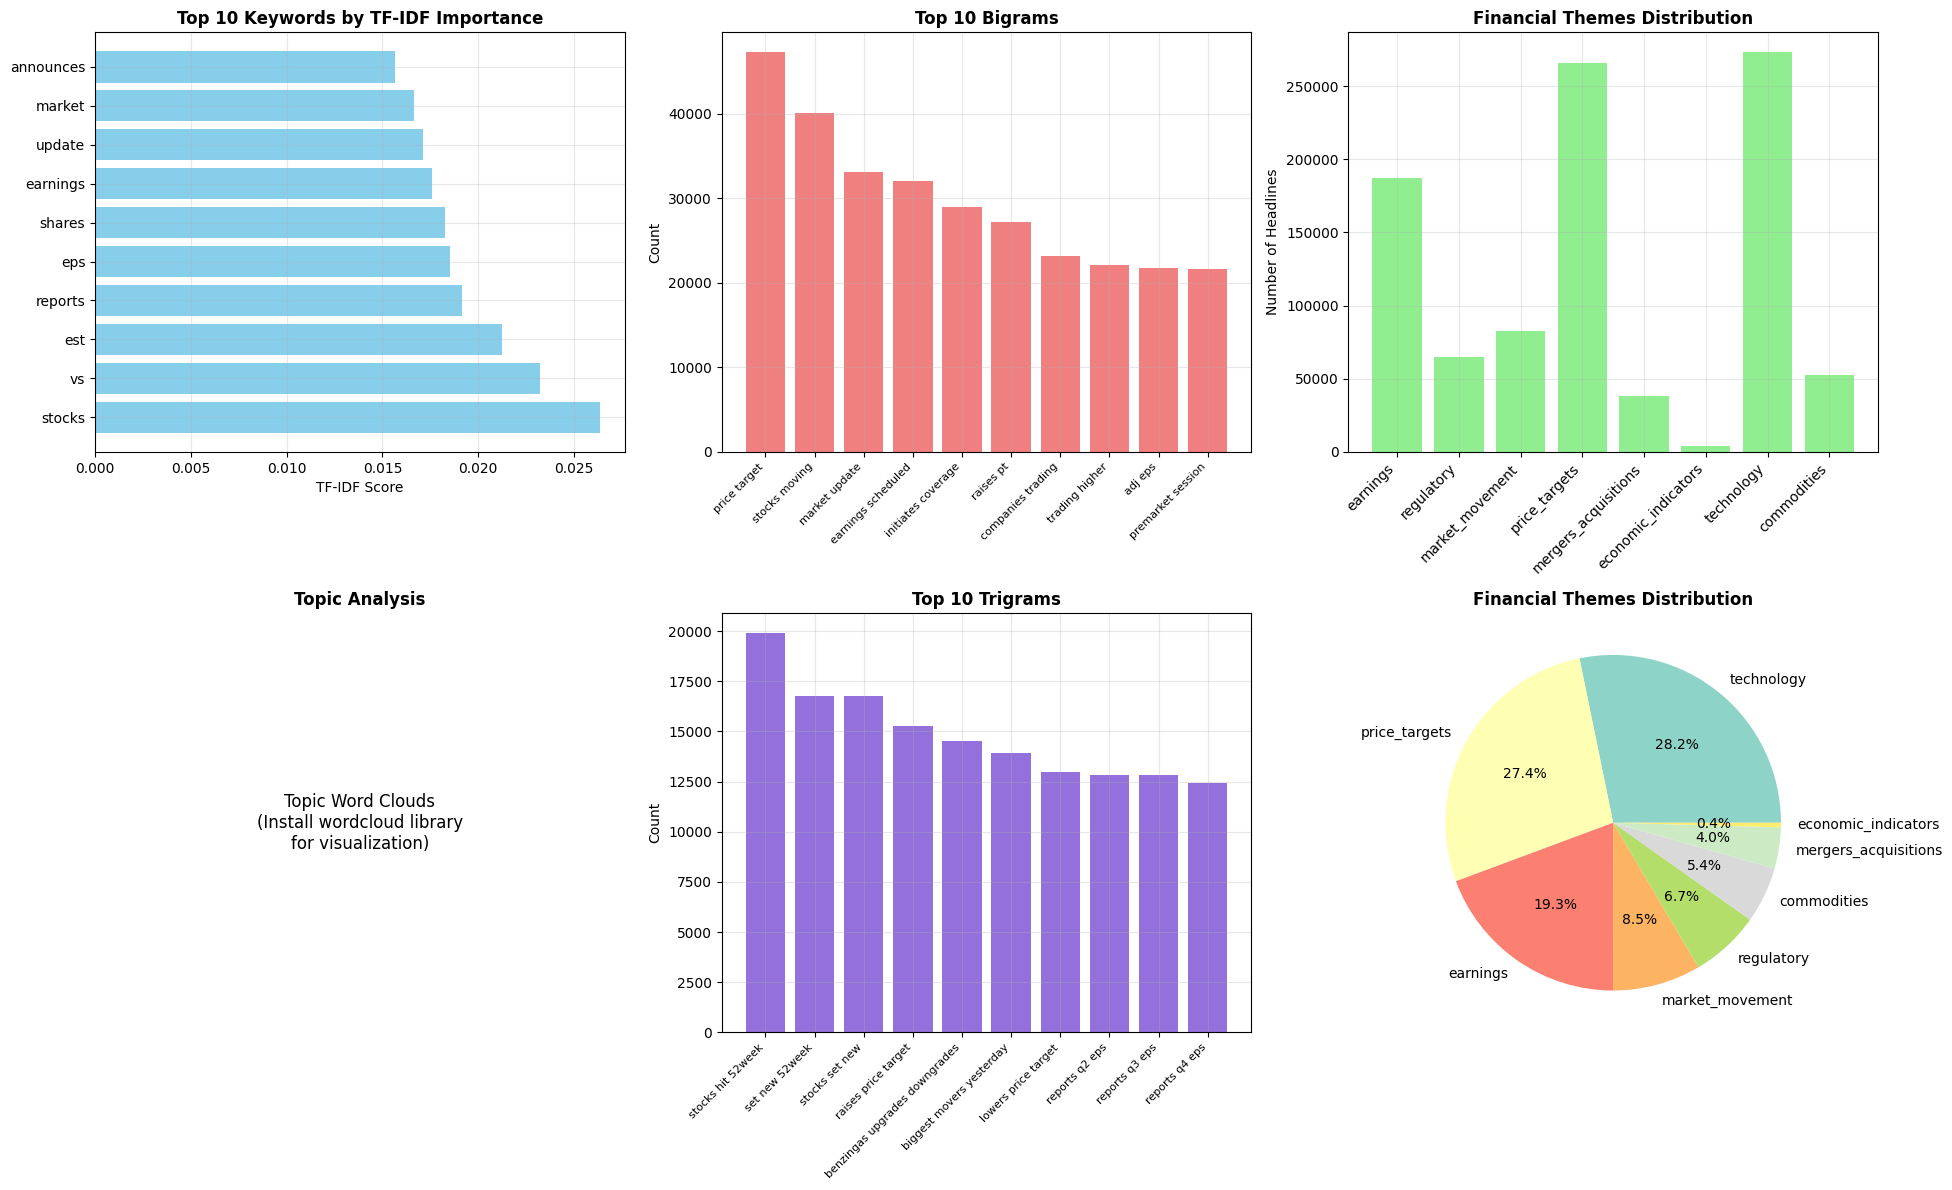

Comprehensive NLP visualizations generated!


In [9]:
# Create comprehensive visualizations
fig = plt.figure(figsize=(20, 12))

# 1. Top TF-IDF Keywords
ax1 = plt.subplot(2, 3, 1)
top_10_keywords = top_keywords.head(10)
bars = ax1.barh(range(len(top_10_keywords)), top_10_keywords['tfidf_score'], color='skyblue')
ax1.set_yticks(range(len(top_10_keywords)))
ax1.set_yticklabels(top_10_keywords['keyword'], fontsize=10)
ax1.set_xlabel('TF-IDF Score')
ax1.set_title('Top 10 Keywords by TF-IDF Importance', fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. Common Bigrams
ax2 = plt.subplot(2, 3, 2)
top_10_bigrams = phrase_analysis['bigrams'].head(10)
ax2.bar(range(len(top_10_bigrams)), top_10_bigrams['count'], color='lightcoral')
ax2.set_xticks(range(len(top_10_bigrams)))
ax2.set_xticklabels(top_10_bigrams['phrase'], rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('Count')
ax2.set_title('Top 10 Bigrams', fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Financial Themes
ax3 = plt.subplot(2, 3, 3)
themes_df = pd.DataFrame(list(theme_analysis.items()), columns=['Theme', 'Count'])
ax3.bar(range(len(themes_df)), themes_df['Count'], color='lightgreen')
ax3.set_xticks(range(len(themes_df)))
ax3.set_xticklabels(themes_df['Theme'], rotation=45, ha='right')
ax3.set_ylabel('Number of Headlines')
ax3.set_title('Financial Themes Distribution', fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4. Topic Word Clouds (placeholder - would need wordcloud library)
ax4 = plt.subplot(2, 3, 4)
ax4.text(0.5, 0.5, 'Topic Word Clouds\n(Install wordcloud library\nfor visualization)', 
         ha='center', va='center', transform=ax4.transAxes, fontsize=12)
ax4.set_title('Topic Analysis', fontweight='bold')
ax4.axis('off')

# 5. Common Trigrams
ax5 = plt.subplot(2, 3, 5)
if 'trigrams' in phrase_analysis:
    top_10_trigrams = phrase_analysis['trigrams'].head(10)
    ax5.bar(range(len(top_10_trigrams)), top_10_trigrams['count'], color='mediumpurple')
    ax5.set_xticks(range(len(top_10_trigrams)))
    ax5.set_xticklabels(top_10_trigrams['phrase'], rotation=45, ha='right', fontsize=8)
    ax5.set_ylabel('Count')
    ax5.set_title('Top 10 Trigrams', fontweight='bold')
    ax5.grid(True, alpha=0.3)

# 6. Theme Distribution Pie Chart
ax6 = plt.subplot(2, 3, 6)
themes_df_sorted = themes_df.sort_values('Count', ascending=False)
colors = plt.cm.Set3(np.linspace(0, 1, len(themes_df_sorted)))
ax6.pie(themes_df_sorted['Count'], labels=themes_df_sorted['Theme'], autopct='%1.1f%%', colors=colors)
ax6.set_title('Financial Themes Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

print("Comprehensive NLP visualizations generated!")

## 8. Summary Report

In [10]:
# Generate comprehensive NLP analysis summary
print("=" * 80)
print("ADVANCED TEXT ANALYSIS SUMMARY")
print("=" * 80)

# Dataset Overview
print(f"\n📊 DATASET OVERVIEW:")
print(f"   • Total Headlines Analyzed: {len(df):,}")
print(f"   • Average Headline Length: {df['headline'].str.len().mean():.1f} characters")
print(f"   • Unique Publishers: {df['publisher'].nunique()}")

# Key Findings
print(f"\n🔍 KEY FINDINGS:")
print(f"   • Top TF-IDF Keyword: '{top_keywords.iloc[0]['keyword']}' (score: {top_keywords.iloc[0]['tfidf_score']:.4f})")
if 'bigrams' in phrase_analysis and len(phrase_analysis['bigrams']) > 0:
    print(f"   • Most Common Bigram: '{phrase_analysis['bigrams'].iloc[0]['phrase']}' ({phrase_analysis['bigrams'].iloc[0]['count']} occurrences)")
if 'trigrams' in phrase_analysis and len(phrase_analysis['trigrams']) > 0:
    print(f"   • Most Common Trigram: '{phrase_analysis['trigrams'].iloc[0]['phrase']}' ({phrase_analysis['trigrams'].iloc[0]['count']} occurrences)")

# Financial Themes
print(f"\n💰 FINANCIAL THEMES:")
dominant_theme = max(theme_analysis.items(), key=lambda x: x[1])
print(f"   • Dominant Theme: {dominant_theme[0].replace('_', ' ').title()} ({dominant_theme[1]} headlines)")
print(f"   • Theme Coverage: {len([t for t in theme_analysis.values() if t > 0])} different themes detected")

# Topics Discovered
print(f"\n📚 TOPICS DISCOVERED:")
print(f"   • Number of Topics: {len(topics)}")
print(f"   • Sample Topic Words: {', '.join(topics[0]['words'][:5])}")

print("\n" + "=" * 80)
print("NLP ANALYSIS COMPLETE")
print("=" * 80)

ADVANCED TEXT ANALYSIS SUMMARY

📊 DATASET OVERVIEW:
   • Total Headlines Analyzed: 1,407,328
   • Average Headline Length: 73.1 characters
   • Unique Publishers: 1034

🔍 KEY FINDINGS:
   • Top TF-IDF Keyword: 'stocks' (score: 0.0263)
   • Most Common Bigram: 'price target' (47266 occurrences)
   • Most Common Trigram: 'stocks hit 52week' (19903 occurrences)

💰 FINANCIAL THEMES:
   • Dominant Theme: Technology (273120 headlines)
   • Theme Coverage: 8 different themes detected

📚 TOPICS DISCOVERED:
   • Number of Topics: 5
   • Sample Topic Words: vs, est, eps, reports, sales

NLP ANALYSIS COMPLETE
